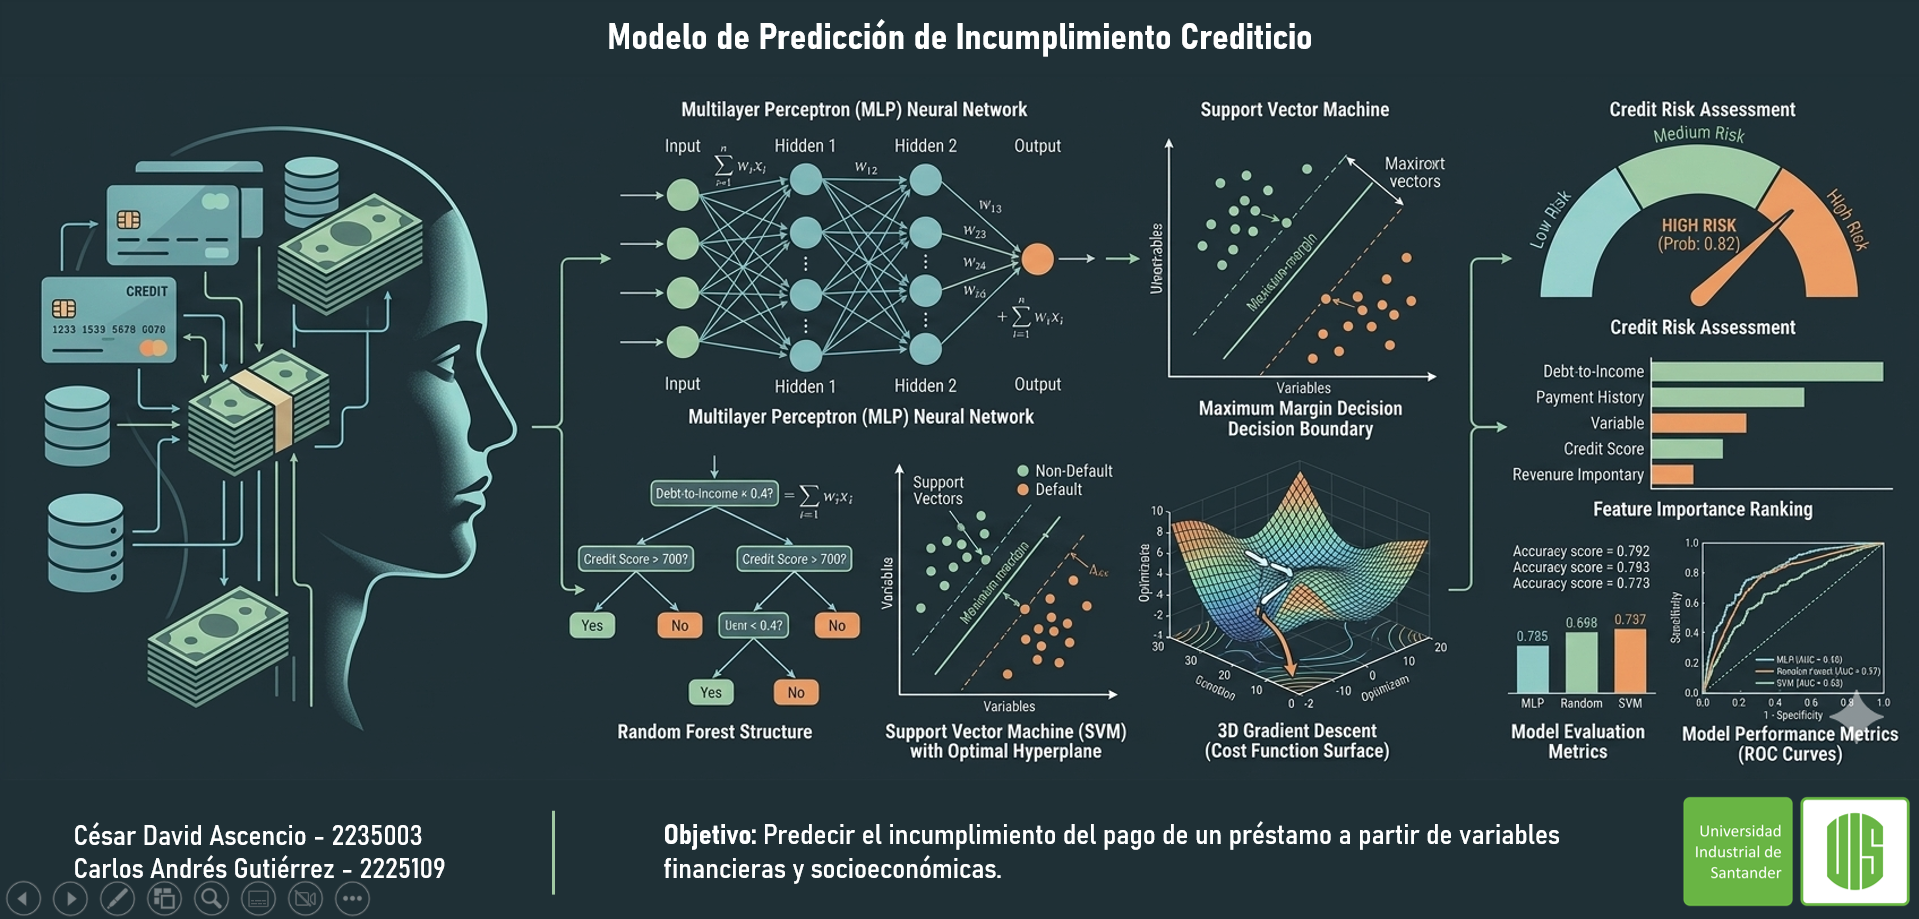

Buscamos predecir si una persona va a incumplir el pago de un préstamo usando técnicas de Machine Learning. A partir de variables financieras, se entrenaron y compararon modelos de clasificación para determinar cuál predice mejor el riesgo de incumplimiento de un solicitante de crédito.

**Dataset:** [Credit Risk Dataset — Kaggle](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)  


Integrantes:
  - Carlos Andres Gutierrez Rodriguez - 2225109
  - César David Ascencio Becerra      - 2235003





Librerias:

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')

## **ENTREGA 1**

 **Introduccion del Dataset**

En este proyecto se utilizará el **Credit Risk Dataset**, disponible en la plataforma [Kaggle](https://www.kaggle.com/datasets). Este conjunto de datos contiene información sobre solicitantes de préstamos y diferentes factores relacionados con su perfil financiero.

El objetivo del análisis es estudiar las características de los solicitantes y **evaluar el riesgo crediticio** asociado a un préstamo. Para ello, el dataset incluye variables como la edad del solicitante, ingresos, tipo de vivienda, duración del empleo, monto del préstamo, tasa de interés e historial crediticio.

La variable principal de interés es **loan_status**, la cual indica si un préstamo representa un posible riesgo de incumplimiento. A partir de estas variables se realizará un análisis exploratorio del dataset y posteriormente se aplicará un modelo de clasificación para predecir el riesgo crediticio.

### **Importacion del Dataset**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/course-AI/credit_risk_dataset.csv')
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


###  **1.a Exploracion inicial del Dataset**

#### **Verificacion del Dataset**

In [ ]:
filas, columnas = df.shape
print("DATASET SUMMARY")
print("-" * 30)

print(f"- Filas: {filas:,}")
print(f"- Columnas: {columnas}")

print("\nRequisitos del proyecto")
print(f"Filas >= 300:   {filas >= 300}")
print(f"Columnas >= 10: {columnas >= 10}")

DATASET SUMMARY
------------------------------
- Filas: 32,581
- Columnas: 12

Requisitos del proyecto
Filas >= 300:   True
Columnas >= 10: True


Como requisito del proyecto, el dataset debe contener al menos 300 filas y 10 columnas.Para verificar que el conjunto de datos cumple con estas condiciones, se utiliza el atributo **shape** de pandas, el cual permite obtener el número de **filas (observaciones) y columnas (variables)** presentes en el dataset.

Esta verificación permite confirmar que el dataset tiene un tamaño suficiente para realizar el análisis exploratorio y aplicar modelos de aprendizaje automático de manera adecuada.

 #### **1. df.head()**


In [ ]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


Se muestran las primeras observaciones del dataset usando **`df.head()`**. Lo que nos permite tener una idea general de como estan estructurados los datos, los nombres de las columnas, ademas de que tipo de informacion tiene cada variable.

#### **2. df.columns**

In [ ]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

Se **listan** los nombres de todas las columnas presentes en el dataset para identificar las variables disponibles que serán utilizadas en el análisis.

#### **3. df.info()**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


La funcion **`df.info()`** permite observar informacion general sobre el Dataset, tal como:

- número total de registros
- número de columnas
- tipo de dato de cada variable
- cantidad de valores no nulos

Esto ayuda a identificar posibles valores faltantes y entender el tipo de datos con los que se va a trabajar.




#### **4. df.describe()**

In [ ]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


La función **`df.describe()`** muestra métricas como:

- Media
- Desviación estándar
- Valores mínimos y máximos
- Percentiles

Esto permite entender la distribución general de los datos.

#### **5. df.shape()**

In [ ]:
print(f'Filas:    {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')

Filas:    32,581
Columnas: 12


Este devuelve una tupla con el número de **filas (observaciones)** y **columnas (variables)** del conjunto de datos.



#### **Valores nulos por columna**

In [ ]:
nulos = df.isnull().sum()
#print(nulos)
pct   = (nulos / len(df) * 100).round(2)
#print(pct)
resumen = pd.DataFrame({'Valores Nulos': nulos, 'Porcentaje (%)': pct})
display(resumen[resumen['Valores Nulos'] > 0])

,Valores Nulos,Porcentaje (%)
person_emp_length,895,2.75
loan_int_rate,3116,9.56


Antes de realizar cualquier análisis o aplicar modelos de aprendizaje automático, es importante verificar si el dataset contiene **valores faltantes (null o missing values)**, ya que estos pueden afectar el rendimiento de los modelos y generar errores durante el procesamiento de datos.

#### **IQR — Detección de Outliers**


- **Outlier inferior:** x < Q1 − 1.5 × IQR  
- **Outlier superior:** x > Q3 + 1.5 × IQR

In [ ]:
cols_num = df.select_dtypes(include=[np.number]).columns.tolist()
if 'loan_status' in cols_num:
    cols_num.remove('loan_status')

resultados = []
for col in cols_num:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR # valor min para ser Outliner
    lim_sup = Q3 + 1.5 * IQR
    n_inf = (df[col] < lim_inf).sum() # num debajo del lim_inf
    n_sup = (df[col] > lim_sup).sum() # num emcima del lim_sup

    resultados.append({
        'Columna': col,
        'Q1': round(Q1, 2), 'Q3': round(Q3, 2), 'IQR': round(IQR, 2),
        'Límite Inf.': round(lim_inf, 2), 'Límite Sup.': round(lim_sup, 2),
        'Outliers ↓': n_inf, 'Outliers ↑': n_sup,
        'Total': n_inf + n_sup,
        '% del total': round((n_inf + n_sup) / len(df) * 100, 2)
    })

#print(len(df))
display(pd.DataFrame(resultados))

,Columna,Q1,Q3,IQR,Límite Inf.,Límite Sup.,Outliers ↓,Outliers ↑,Total,% del total
0,person_age,23.00,30.00,7.00,12.50,40.50,0,1494,1494,4.59
1,person_income,38500.00,79200.00,40700.00,-22550.00,140250.00,0,1484,1484,4.55
2,person_emp_length,2.00,7.00,5.00,-5.50,14.50,0,853,853,2.62
3,loan_amnt,5000.00,12200.00,7200.00,-5800.00,23000.00,0,1689,1689,5.18
4,loan_int_rate,7.90,13.47,5.57,-0.46,21.83,0,6,6,0.02
5,loan_percent_income,0.09,0.23,0.14,-0.12,0.44,0,651,651,2.00
6,cb_person_cred_hist_length,3.00,8.00,5.00,-4.50,15.50,0,1142,1142,3.51


Este display muestra un diagnostico de outliers para **todas las variables numericas** existentes en el Datset.


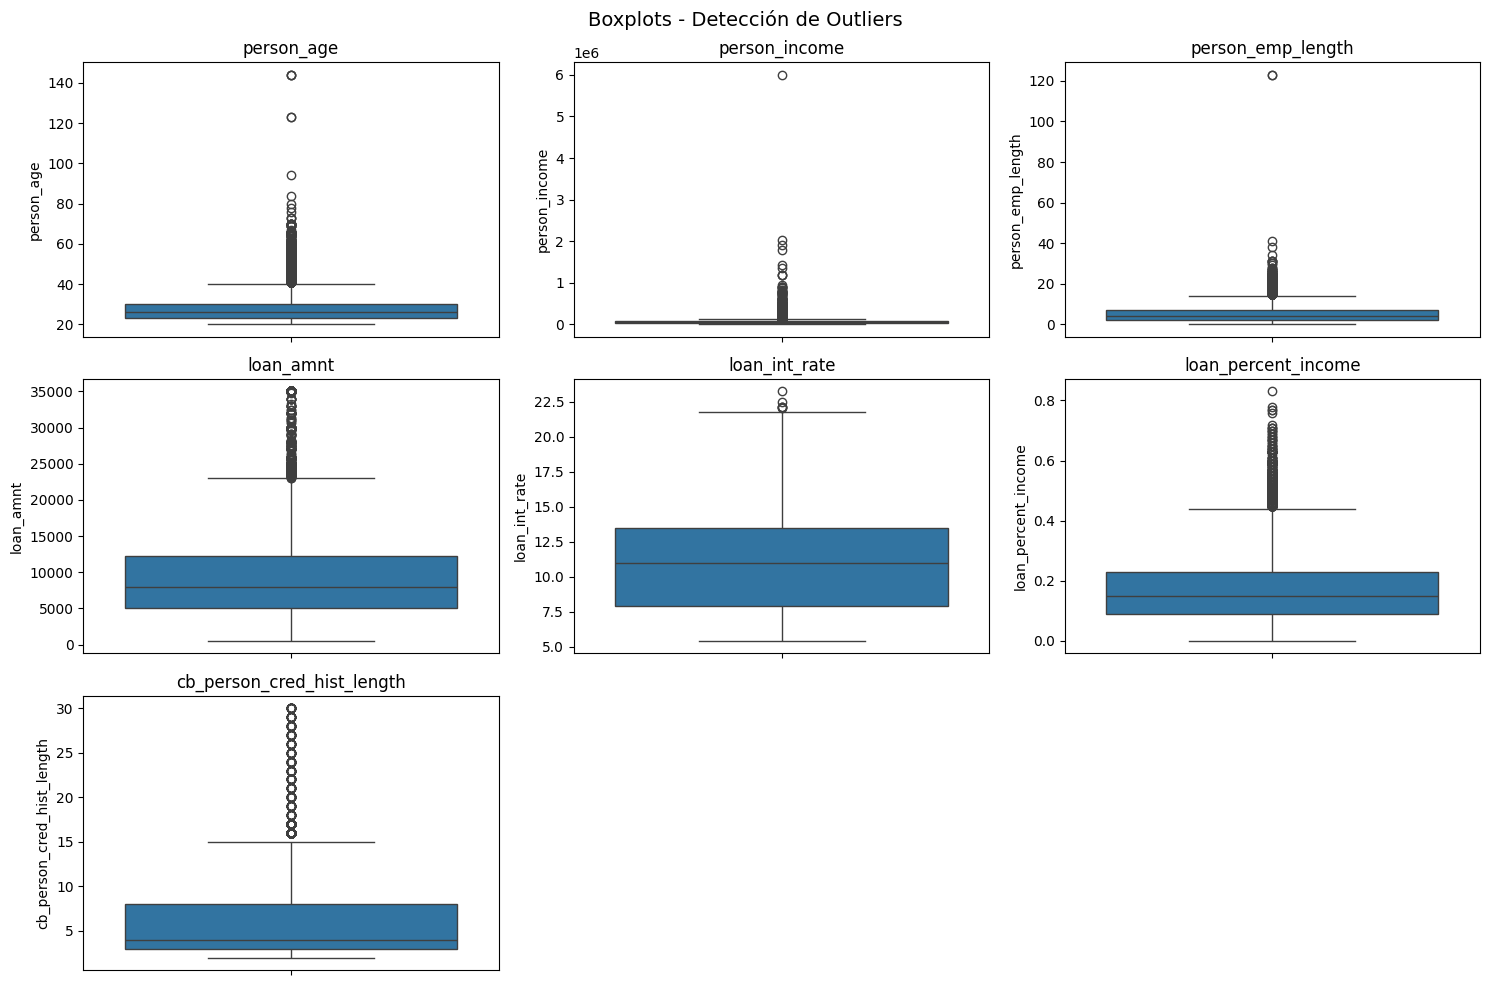

In [ ]:
# Boxplots para visualizar outliers
import seaborn as sns

plt.figure(figsize=(15, 10))

for i, col in enumerate(cols_num):
  plt.subplot(3, 3, i + 1)
  sns.boxplot(y=df[col].dropna())
  plt.title(col)

plt.suptitle('Boxplots - Detección de Outliers', fontsize=14)
plt.tight_layout()
plt.show()

### **1.b Columnas Categóricas y Numéricas**

En esta seccion de identifican las variables segun su tipo de dato.
- **Variables numéricas**: contienen valores cuantitativos que permiten realizar cálculos estadísticos.
- **Variables categóricas**: representan categorías o grupos, como tipos de vivienda o motivos del préstamo.

Para separar estas variables se utilizan las funciones de pandas que permiten seleccionar columnas según su tipo de dato.

#### **Distribución de variables categóricas** "proporciones"

In [ ]:
cols_num_all = df.select_dtypes(include=[np.number]).columns.tolist()
cols_cat     = df.select_dtypes(include=['object', 'category']).columns.tolist() # 'object' y 'category' tipos de datos en panda

print(f'Columnas NUMÉRICAS ({len(cols_num_all)}):')

for c in cols_num_all:
    print(f'   • {c}')

print(f'\nColumnas CATEGÓRICAS ({len(cols_cat)}):')
for c in cols_cat:
    print(f'   • {c}  →  {df[c].nunique()} valores únicos: {df[c].unique().tolist()}')

Columnas NUMÉRICAS (8):
   • person_age
   • person_income
   • person_emp_length
   • loan_amnt
   • loan_int_rate
   • loan_status
   • loan_percent_income
   • cb_person_cred_hist_length

Columnas CATEGÓRICAS (4):
   • person_home_ownership  →  4 valores únicos: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
   • loan_intent  →  6 valores únicos: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
   • loan_grade  →  7 valores únicos: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
   • cb_person_default_on_file  →  2 valores únicos: ['Y', 'N']


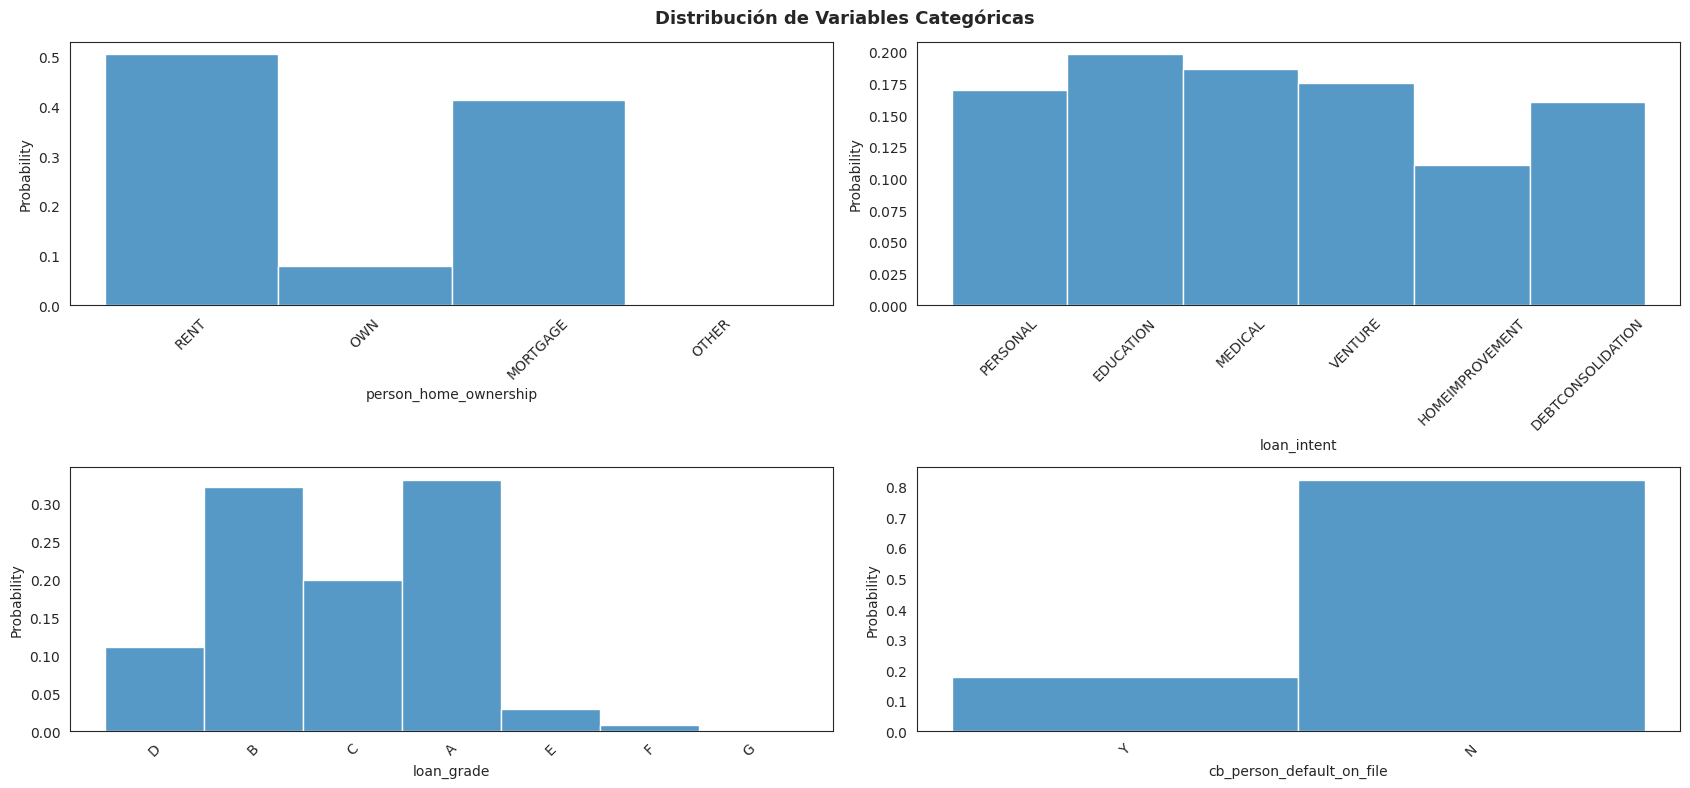

In [ ]:
sns.set_style("white")
plt.figure(figsize=(17, 8))

for i, col in enumerate(cols_cat):
    plt.subplot(2, 2, i + 1)
    ax = sns.histplot(df[col], bins=df[col].nunique(), stat='probability')
    ax.set(xlabel=col)
    plt.xticks(rotation=45)

plt.suptitle('Distribución de Variables Categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

###**Tarea: Clasificación Binaria Supervisada**



El objetivo del proyecto es construir un modelo de **clasificación binaria supervisada** que permita predecir el riesgo crediticio de un préstamo.

La variable objetivo del modelo es **`loan_status`**, la cual indica el estado del préstamo:


| Clase | Significado |
|-------|-------------|
| `0`   | Pago correcto |
| `1`   | Incumplimiento |

En esta sección se analiza la distribución de la variable objetivo para identificar si existe un desbalance entre las clases.

Distribución de loan_status:
  Clase 0 — Pago correcto:  25,473  (78.2%)
  Clase 1 — Incumplimiento:  7,108  (21.8%)


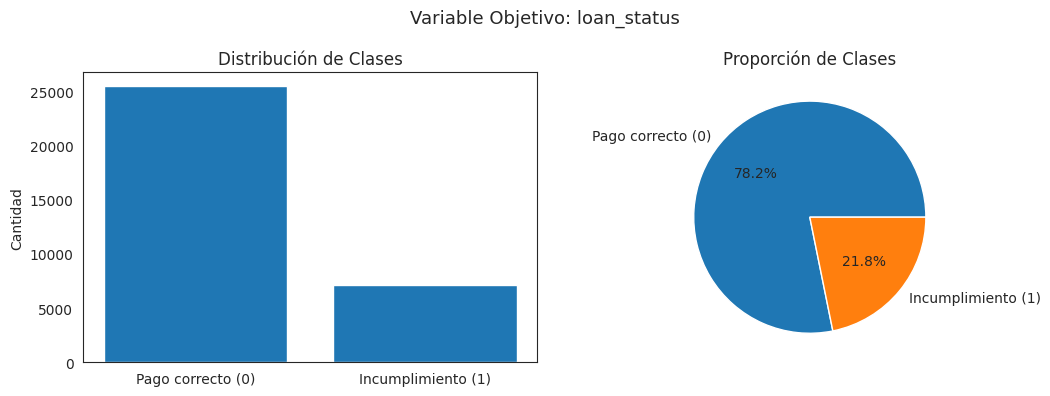


Ratio de desbalance (0/1): 3.58
Dataset desbalanceado.


In [ ]:
conteo = df['loan_status'].value_counts()
#print(conteo)
pct    = df['loan_status'].value_counts(normalize=True) * 100

print('Distribución de loan_status:')
print(f'  Clase 0 — Pago correcto:  {conteo[0]:>6,}  ({pct[0]:.1f}%)')
print(f'  Clase 1 — Incumplimiento: {conteo[1]:>6,}  ({pct[1]:.1f}%)')

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(['Pago correcto (0)', 'Incumplimiento (1)'], conteo.values, width=0.8)
plt.title('Distribución de Clases')
plt.ylabel('Cantidad')

plt.subplot(1, 2, 2)
plt.pie(conteo.values,
        labels=['Pago correcto (0)', 'Incumplimiento (1)'],
        autopct='%1.1f%%')
plt.title('Proporción de Clases')

plt.suptitle('Variable Objetivo: loan_status', fontsize=13)
plt.tight_layout()
plt.show()

ratio = conteo[0] / conteo[1]
print(f'\nRatio de desbalance (0/1): {ratio:.2f}')
if ratio > 2:  # 3 por convención general, 2 más estricto
    print('Dataset desbalanceado.')
else:
    print('Dataset relativamente balanceado.')

### **RESUMEN FINAL**

In [ ]:
print('=' * 50)
print('     RESUMEN — Pre-entrega 1')
print('=' * 50)
print(f'  Filas:               {df.shape[0]:>10,}')
print(f'  Columnas:            {df.shape[1]:>10}')
print(f'  Cols. numéricas:     {len(cols_num_all):>10}')
print(f'  Cols. categóricas:   {len(cols_cat):>10}')
print(f'  Valores nulos:       {df.isnull().sum().sum():>10}')
print(f'  Tarea:               Clasificación Binaria')
print(f'  Variable objetivo:   loan_status (0 / 1)')
print('=' * 50)

     RESUMEN — Pre-entrega 1
  Filas:                   32,581
  Columnas:                    12
  Cols. numéricas:              8
  Cols. categóricas:            4
  Valores nulos:             4011
  Tarea:               Clasificación Binaria
  Variable objetivo:   loan_status (0 / 1)


## **ENTREGA 2**

### **1. Limpieza del dataset**

Los valores faltantes se concentran únicamente en dos columnas:

- **`loan_int_rate:`** 3,116 nulos → **9.56%**


- **`person_emp_length:`** 895 nulos → **2.75%**

El resto del dataset está completo, lo que permite aplicar imputación puntual sin sacrificar observaciones. Eliminar las filas con nulos en **`loan_int_rate`** significaría descartar casi **1 de cada 10 registros**, una pérdida innecesaria dado que la columna tiene suficiente información para estimar un valor representativo.Para **`person_emp_length`** la proporción es menor, pero la presencia de valores extremos hace que la imputación requiera una estrategia robusta frente a outliers.

In [ ]:
df.isna().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


####**Metodo de imputacion de valores NaN**

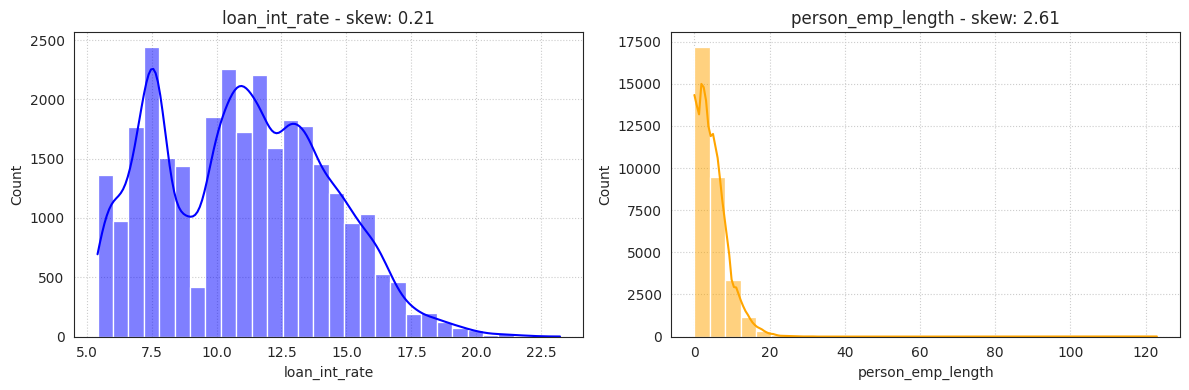

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['loan_int_rate'], kde=True, color='blue', bins=30)
plt.grid(True, linestyle='dotted', alpha=1)
plt.title('loan_int_rate - skew: 0.21')

plt.subplot(1, 2, 2)
sns.histplot(df['person_emp_length'], kde=True, color='orange', bins=30)
plt.title('person_emp_length - skew: 2.61')
plt.grid(True, linestyle='dotted', alpha=1)
plt.tight_layout()
plt.show()

Los histogramas confirman visualmente por qué se eligio la mediana para imputar ambas columnas.

***`loan_int_rate`***

- Tiene un skew de **0.21**, aunque es casi simétrica, se puede ver que la distribución tiene dos picos (bimodal) y una cola hacia la derecha,
hay tasas de interés extremadamente altas que jalarían la media hacia arriba. La mediana es más segura en este caso.

***`person_emp_length`***

- Con skew de **2.61** es el caso más claro, la gran mayoría de personas **tiene entre 0 y 5 años de experiencia laboral**. Tambien hay casos extremos que llegan hasta 120 años, lo cual son errores de datos evidentes.

Si hubiéramos usado la media, esos valores absurdos habrían inflado el valor de imputación, rellenando los NaN con un número que no representa a la mayoría de los registros. La mediana ignora esos extremos y refleja el comportamiento real de la columna. Dado que **`person_emp_length`** es un indicador de estabilidad laboral — factor relevante para evaluar la capacidad de pago — una imputación correcta en esta columna tiene impacto directo en la calidad de las predicciones del modelo.

**Implementacion**

In [ ]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print(df.isnull().sum())

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


Tras aplicar la imputación con mediana, el dataset queda sin valores faltantes en ninguna de sus 12 columnas, confirmando que la limpieza fue exitosa.

### **2. Particionado**

**Identificacion**

In [ ]:
cols_cat = df.select_dtypes(include=['object', 'category']).columns.tolist() # 'object' y 'category' tipos de datos en panda

print(f'\nColumnas CATEGÓRICAS ({len(cols_cat)}):')
for c in cols_cat:
    print(f'   • {c}  →  {df[c].nunique()} valores únicos: {df[c].unique().tolist()}')


Columnas CATEGÓRICAS (4):
   • person_home_ownership  →  4 valores únicos: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
   • loan_intent  →  6 valores únicos: ['PERSONAL', 'EDUCATION', 'MEDICAL', 'VENTURE', 'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
   • loan_grade  →  7 valores únicos: ['D', 'B', 'C', 'A', 'E', 'F', 'G']
   • cb_person_default_on_file  →  2 valores únicos: ['Y', 'N']


**Implementacion**

Las 4 columnas categóricas se codificaron numéricamente con **`pd.factorize()`** para que los modelos puedan procesarlas. La variable objetivo **`loan_status`** se separó como vector y, y el resto de columnas conforman la matriz de features X.

In [ ]:
from sklearn.model_selection import train_test_split
np.random.seed(21)

for col in ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']:
  df[col], _ = pd.factorize(df[col])

y = df['loan_status']
X = df.drop(columns=['loan_status'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=21)

Los valores faltantes no están distribuidos en todo el dataset, sino concentrados únicamente en **`loan_int_rate`** y **`person_emp_length`**. Esto permite aplicar imputación sin perder una cantidad importante de registros.

### **3. Métodos de Estimación**

#### **Decision Tree `DT`**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
np.random.seed(21)

profundidades = [2, 5, 10, 15, 20, 30, 50, 100]
accuracies = []

for i in profundidades:
  est1 = DecisionTreeClassifier(max_depth=i, random_state=21)
  est1.fit(X_train, y_train)
  metrica1 = accuracy_score(y_test, est1.predict(X_test))
  accuracies.append(metrica1)

mejor_depth = profundidades[accuracies.index(max(accuracies))]
print(f'\nMejor max_depth: {mejor_depth} → accuracy: {max(accuracies):.4f}')


Mejor max_depth: 10 → accuracy: 0.9254


El modelo alcanzó su mejor accuracy con **`max_depth=10`**, obteniendo un **92.54%** de aciertos sobre el conjunto de test. Esto significa que de cada 100 personas, el modelo clasifica correctamente si van a incumplir o no en aproximadamente 93 casos.

El hecho de que el mejor resultado se dé con profundidad 10 y no con valores más altos como 50 o 100 indica que el modelo **no necesita hacerse muy complejo para aprender bien los patrones del dataset**, con 10 niveles de preguntas ya captura suficiente información sobre variables como la tasa de interés, el ingreso y el historial crediticio para hacer una buena predicción.

#### **Random Forest `RF`**

In [ ]:
from sklearn.ensemble import RandomForestClassifier
np.random.seed(21)

estimators = [60, 65, 70, 75, 80, 90, 100]
accuracies = []

for i in estimators:
  est2 = RandomForestClassifier(n_estimators=i, random_state=21)
  est2.fit(X_train, y_train)
  metrica2 = accuracy_score(y_test, est2.predict(X_test))
  accuracies.append(metrica2)

mejor_est = estimators[accuracies.index(max(accuracies))]
print(f'\nMejor n_stimators: {mejor_est} → accuracy: {max(accuracies):.4f}')


Mejor n_stimators: 70 → accuracy: 0.9285


Con un **92.85%** de accuracy, el modelo clasifica correctamente a casi 93 de cada 100 personas en cuanto a si van a incumplir o no su préstamo. Esto significa que con **70 árboles el modelo tiene suficiente información para tomar buenas decisiones crediticias**, lo cual en un contexto real le permitiría a un banco reducir significativamente el riesgo de prestarle dinero a alguien que no va a pagar.



#### **Support Virtual Machine `SVM`**



El SVC calcula distancias entre puntos. Si **person_income** tiene valores en millones y loan_int_rate en decimales, el modelo le da muchísimo más peso a **person_income** simplemente por su magnitud, no porque sea más importante. ***StandardScaler*** lleva todas las columnas a la misma escala (media=0, std=1), así el modelo trata todas las features de forma equitativa.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trainS = scaler.fit_transform(X_train)
X_testS = scaler.transform(X_test)

In [ ]:
def est_SVC(df, kernel, iter):
  from sklearn.svm import SVC
  from sklearn.metrics import accuracy_score
  import matplotlib.pyplot as plt
  np.random.seed(21)

  accuracies = []
  for i in iter:
      estSVC = SVC(kernel=kernel, random_state=21, max_iter=i)
      estSVC.fit(X_trainS, y_train)
      mSVC = accuracy_score(y_test, estSVC.predict(X_testS))
      accuracies.append(mSVC)

  mejor_iter = iter[accuracies.index(max(accuracies))]
  print(f'\nKERNEL: {kernel}\nMejor max_iter: {mejor_iter} → accuracy: {max(accuracies):.4f}\n')

kernels = ["linear", "poly", "rbf"]
iteraciones = [5000, 10000, 15000, 20000, 30000, 50000, 100000, 150000]

est_SVC(df, "linear", iteraciones)
est_SVC(df, "poly", iteraciones)
est_SVC(df, "rbf", iteraciones)


KERNEL: linear
Mejor max_iter: 50000 → accuracy: 0.8441


KERNEL: poly
Mejor max_iter: 20000 → accuracy: 0.8822



KeyboardInterrupt: 

### **4. Cross Validation**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trainS = scaler.fit_transform(X_train)
X_testS = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.metrics import make_scorer

estDT = DecisionTreeClassifier(max_depth=10, random_state=21)
estRF = RandomForestClassifier(n_estimators=70, random_state=21)
estSVM = SVC(kernel="rbf", random_state=21, max_iter=15000)

estimadores = [estDT, estRF, estSVM]
txt = ['Decision Tree', 'Random Forest', 'SVM']
kfolds = [10, 20, 50]

for esti, nombre in zip(estimadores, txt):
    print(f"{'='*30} -PROCESANDO- {nombre} {'='*30}")

    for k in kfolds:
        kf = KFold(n_splits=k, shuffle=False)
        s = cross_val_score(esti, X, y, cv=kf, scoring=make_scorer(accuracy_score))

        prom = np.mean(s)
        std = np.std(s)

        print(f"Kfold: {k}\n Promedio = {prom:.4f}\t Std= {std:.4f}")

    print(f"{'='*30} -ESTIMACION COMPLETA- {'='*30}\n")

Para evaluar la robustez de los modelos, utilizamos validación cruzada con diferentes valores de KFolds. Esto nos permitió analizar no solo el rendimiento promedio, sino también la estabilidad mediante la desviación estándar

En el caso de **Decision Tree**, observamos un comportamiento estable, con resultados consistentes entre diferentes particiones. Esto indica que el modelo no depende significativamente del subconjunto de datos evaluado.

Por otro lado, **Random Forest** obtuvo el mejor desempeño global del proyecto, alcanzando un accuracy de 93.13% y la menor desviación estándar entre todos los modelos.

Esto significa que no solo es preciso, sino también altamente consistente, lo cual es fundamental en un entorno financiero donde las decisiones deben ser confiables independientemente del perfil del cliente.

En términos prácticos, aunque **SVM** logra buenos resultados en entrenamiento, su inestabilidad lo hace menos confiable para producción, ya que podría tomar decisiones inconsistentes dependiendo del segmento de clientes evaluado.

### **5. Deep Learning**

In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import StandardScaler
np.random.seed(21)
tf.random.set_seed(21)
tf.keras.utils.set_random_seed(21)

y = df['loan_status']
X = df.drop(columns=['loan_status'])
nc = y.nunique()

# Buena practica, para evitar warnings y comportamientos inesperados en la etapa de entrenamiento
X.columns = range(X.shape[1])
X = X.to_numpy()
y = y.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def get_red(n):
  if n == 1:
    return keras.Sequential([
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])
  elif n == 2:
    return keras.Sequential([
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(64, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(256, activation='relu'),
      keras.layers.Dense(256, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])
  elif n == 3:
    return keras.Sequential([
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(128, activation='relu'),
      keras.layers.Dense(nc, activation='sigmoid')
    ])

def deep_learning(n_red, epoch):
  red = get_red(n_red)
  red.compile(
      optimizer=tf.keras.optimizers.SGD(),
      loss='sparse_categorical_crossentropy',
      metrics=['accuracy']
  )
  red.fit(X_train, y_train, epochs=epoch, verbose=0)
  loss, accuracy = red.evaluate(X_test, y_test, verbose=0)
  return loss, accuracy

epochs = [10, 20, 50]

for i in range(1, 4):
  for epoch in epochs:
    print(f"=== Red: red {i} - Epochs: {epoch} ===")
    loss, accuracy = deep_learning(i, epoch)
    print(f"Accuracy: {accuracy:.4f} - Loss: {loss:.4f}\n")
  print()

En cuanto a Deep Learning, evaluamos tres arquitecturas diferentes. Observamos que las redes más complejas tendían al sobreajuste, mientras que una arquitectura más simple con 50 épocas logró el mejor equilibrio entre rendimiento y generalización, con un accuracy de 89.64%.

Esto sugiere que la complejidad del problema no justifica el uso de modelos profundos, ya que modelos más simples logran resultados comparables con menor costo computacional.

###**6. Conclusión #2**

En conclusión, el modelo más adecuado para este problema es Random Forest, ya que combina alta precisión con una gran estabilidad en validación cruzada.

Su tasa de error aproximada es del 6.8%, lo cual es aceptable en un contexto financiero, y además permite ajustar el umbral de decisión según el nivel de riesgo que la institución esté dispuesta a asumir.

Por estas razones, lo consideramos el modelo más robusto y confiable para implementación en un entorno real.

## **ENTREGA 3**

### **1. MinMaxScaler**

Separar features (X) de la variable objetivo (y)

Instanciar y ajustar el scaler

Convertir a DataFrame para mantener los nombres de columnas

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X = df.drop(columns=['loan_status'])
y = df['loan_status']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

print(f"Shape de X_scaled: {X_scaled_df.shape}")

Shape de X_scaled: (32581, 11)


###**2. Reducción dimensional con PCA**

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=21)
X_pca = pca.fit_transform(X_scaled)

print('Shape original: ', X_scaled.shape)
print('Shape PCA:      ', X_pca.shape)

Shape original:  (32581, 11)
Shape PCA:       (32581, 2)


### **3. K-Means**

In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=2, random_state=21)
kmeans_clusters = kmeans.fit_predict(X_pca)
centroids = kmeans.cluster_centers_

print('Labels únicos:   ', np.unique(kmeans.labels_))
print('Centroides shape:', kmeans.cluster_centers_.shape)

Labels únicos:    [0 1]
Centroides shape: (2, 2)


### **4. DBSCAN**

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

dbs = DBSCAN(eps=0.3, min_samples=5)
dbs.fit_predict(X_pca)

print('Labels únicos:  ', np.unique(dbs.labels_))
print('Puntos ruido:   ', (dbs.labels_ == -1).sum())

Labels únicos:   [0 1]
Puntos ruido:    0


### **4. Original vs K-Means vs DBSCAN**

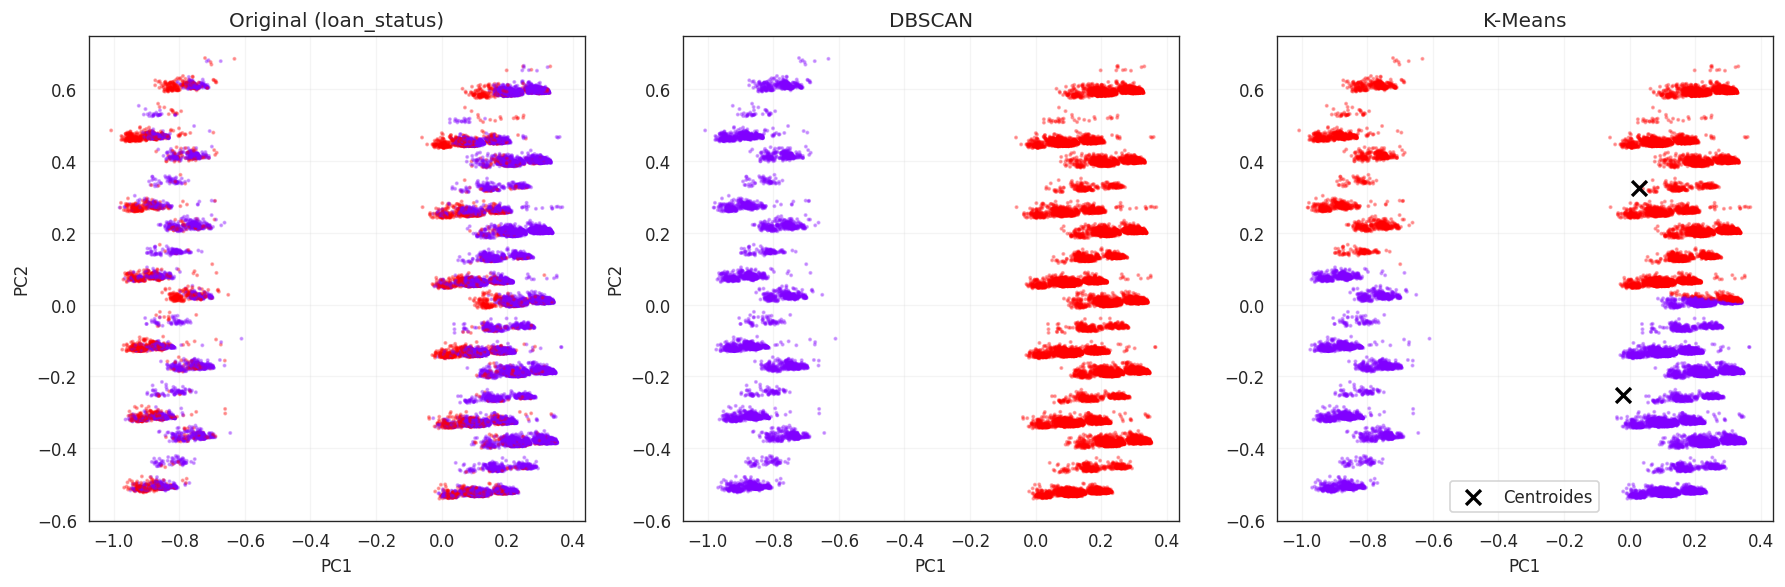

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(131)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='rainbow', s=2, alpha=0.3)
plt.title("Original (loan_status)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)

plt.subplot(132)
plt.title("DBSCAN")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(alpha=0.2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=dbs.labels_, cmap='rainbow', s=2, alpha=0.3)

plt.subplot(133)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='rainbow', s=2, alpha=0.3)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', marker='.', s=80, linewidths=2, label='Centroides')
plt.xlabel("PC1")
plt.title("K-Means")
plt.grid(alpha=0.2)
plt.legend()

plt.tight_layout()
plt.show()